# Codveda task 1 and task 2

## Importing libraries and load dataset

In [3]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt  

df = pd.read_csv(r"E:\Codveda projects\datasets\1) iris.csv")

## Task 1: Inspecting and cleaning the dataset

In [4]:
# Head 5
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [5]:
# tail 5
df.tail()

,sepal_length,sepal_width,petal_length,petal_width,species
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica


In [6]:
# sample data
df.sample(5)

,sepal_length,sepal_width,petal_length,petal_width,species
70,5.9,3.2,4.8,1.8,versicolor
52,6.9,3.1,4.9,1.5,versicolor
1,4.9,3.0,1.4,0.2,setosa
123,6.3,2.7,4.9,1.8,virginica
121,5.6,2.8,4.9,2.0,virginica


In [7]:
# shape

df.shape

(150, 5)

In [8]:
# checking columns

df.columns.to_list()

['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

In [9]:
# dataset info

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [ ]:
# summary statistics

df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [12]:
# checking null values

df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [13]:
# checking duplicates

df.duplicated().sum()

np.int64(3)

In [14]:
# dropping duplicates

df.drop_duplicates(inplace=True)

In [15]:
# re-checking duplicates

df.duplicated().sum()

np.int64(0)

In [16]:
# final shape

df.shape

(147, 5)

## Task 2: EDA

In [17]:
# checking unique species

df["species"].value_counts()

species
versicolor    50
virginica     49
setosa        48
Name: count, dtype: int64

In [40]:
# checking means with species

print("Mean values across the dataset by species: ")
df_mean = df.groupby("species").mean()
display(df_mean)


Mean values across the dataset by species: 


,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.010417,3.431250,1.462500,0.250000
versicolor,5.936000,2.770000,4.260000,1.326000
virginica,6.604082,2.979592,5.561224,2.028571


In [41]:
# checking median with species

print("Median values across the dataset by species: ")
df_median = df.groupby('species').median()
display(df_median)


Median values across the dataset by species: 


,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.0,3.4,1.50,0.2
versicolor,5.9,2.8,4.35,1.3
virginica,6.5,3.0,5.60,2.0


In [42]:
# checking mode with species

print("Mode values across the dataset by species: ")
df_mode = df.groupby("species").agg(lambda x: x.mode().iloc[0])
display(df_mode)


Mode values across the dataset by species: 


,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.0,3.4,1.4,0.2
versicolor,5.5,3.0,4.5,1.3
virginica,6.3,3.0,5.1,1.8


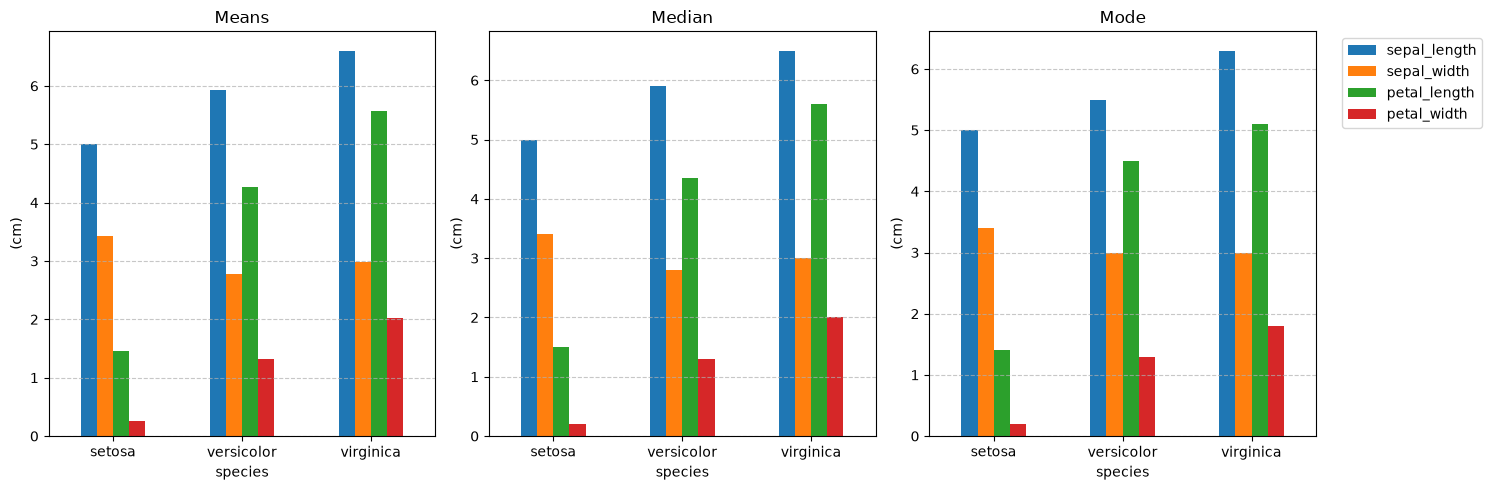

In [46]:
# Visualizing mean, median, mode

plt.figure(figsize=(15,5))

# mean chart
plt.subplot(1, 3, 1)
df_mean.plot(kind="bar", ax=plt.gca(), legend=False )
plt.title("Means")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)
plt.ylabel("(cm)")

# median chart
plt.subplot(1, 3, 2)
df_median.plot(kind="bar", ax= plt.gca(), legend=False)
plt.title("Median")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)
plt.ylabel("(cm)")

# mode chart
plt.subplot(1, 3, 3)
df_mode.plot(kind="bar", ax=plt.gca(), legend=False)
plt.title("Mode")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)
plt.ylabel("(cm)")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


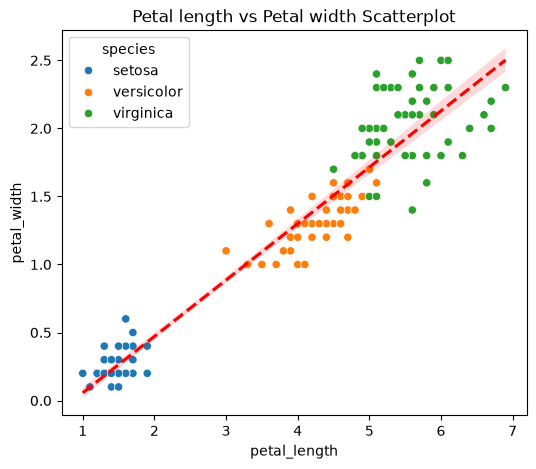

In [56]:
import seaborn as sns

# petal_length vs petal_width scatterplot

plt.figure(figsize=(6,5))
sns.scatterplot(data=df, x="petal_length", y="petal_width", hue="species")
plt.title("Petal length vs Petal width Scatterplot")
sns.regplot(data=df,
            x="petal_length",
            y="petal_width", 
            scatter=False,
            color="Red",
            line_kws={"linestyle" :"--"}  
            )
plt.show()



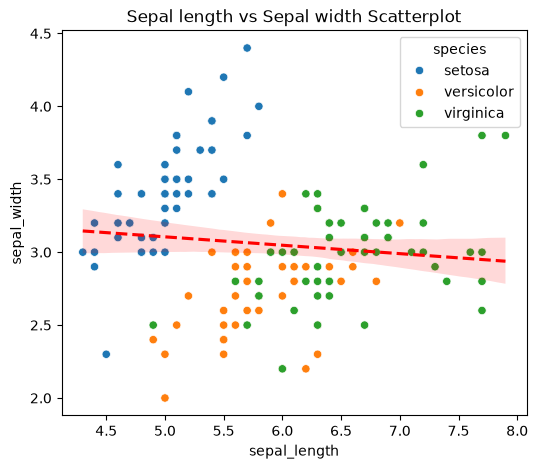

In [62]:
# sepal_length vs sepal_width scatterplot

plt.figure(figsize=(6,5))
sns.scatterplot(data=df, x="sepal_length", y="sepal_width", hue="species")
plt.title("Sepal length vs Sepal width Scatterplot")
sns.regplot(data=df,
            x= "sepal_length",
            y="sepal_width",
            scatter=False,
            line_kws= {"linestyle": "--"},
            color = "red" )
plt.show()

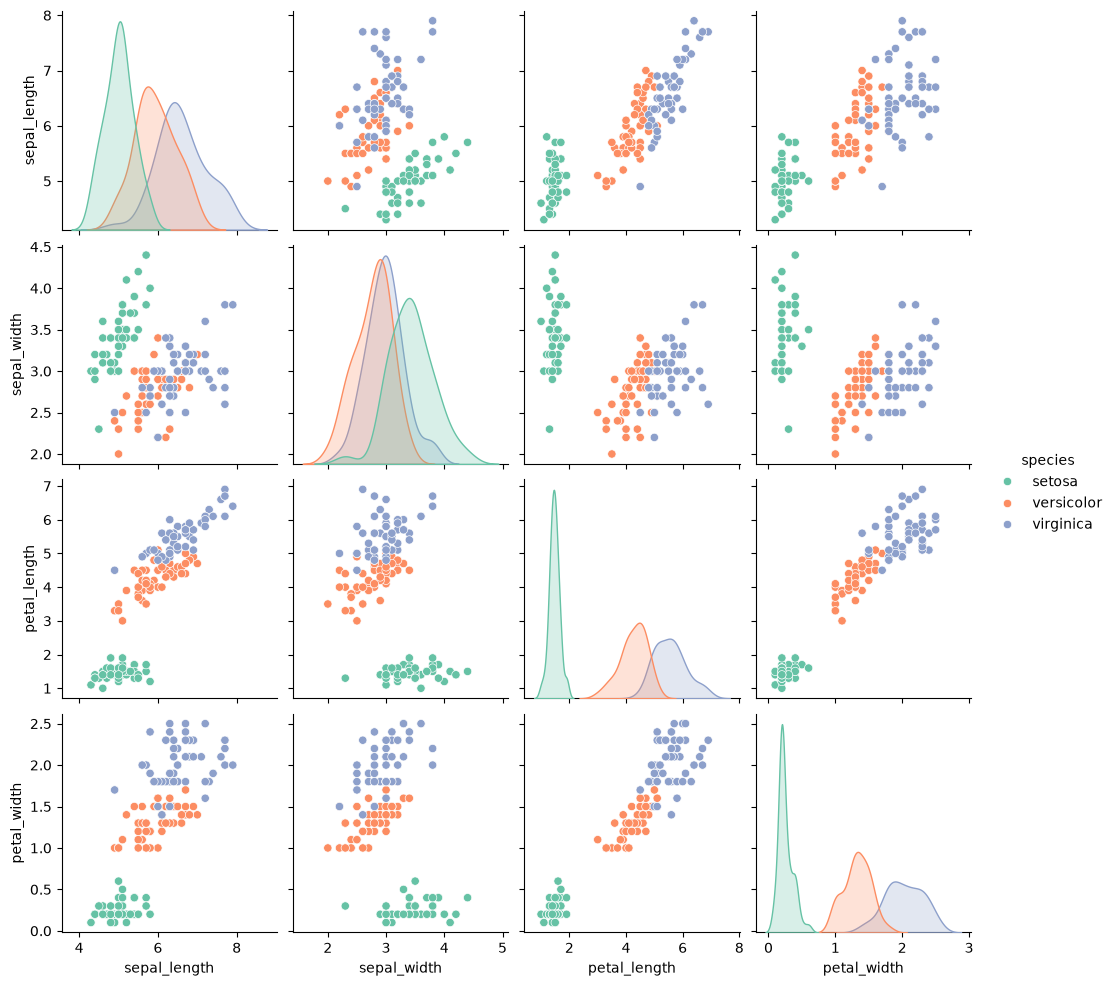

In [ ]:
# Any other correlation between different columns 

sns.pairplot(data= df, hue="species", palette="Set2" )

C:\Users\Asus\AppData\Local\Temp\ipykernel_14568\256615526.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="species", y="sepal_length", ax=axes[0, 0], palette="Set2")
C:\Users\Asus\AppData\Local\Temp\ipykernel_14568\256615526.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="species", y="sepal_width", ax=axes[0, 1], palette="Set2")
C:\Users\Asus\AppData\Local\Temp\ipykernel_14568\256615526.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="species", y="petal_length", ax=axes[1, 0], palette="Set2")


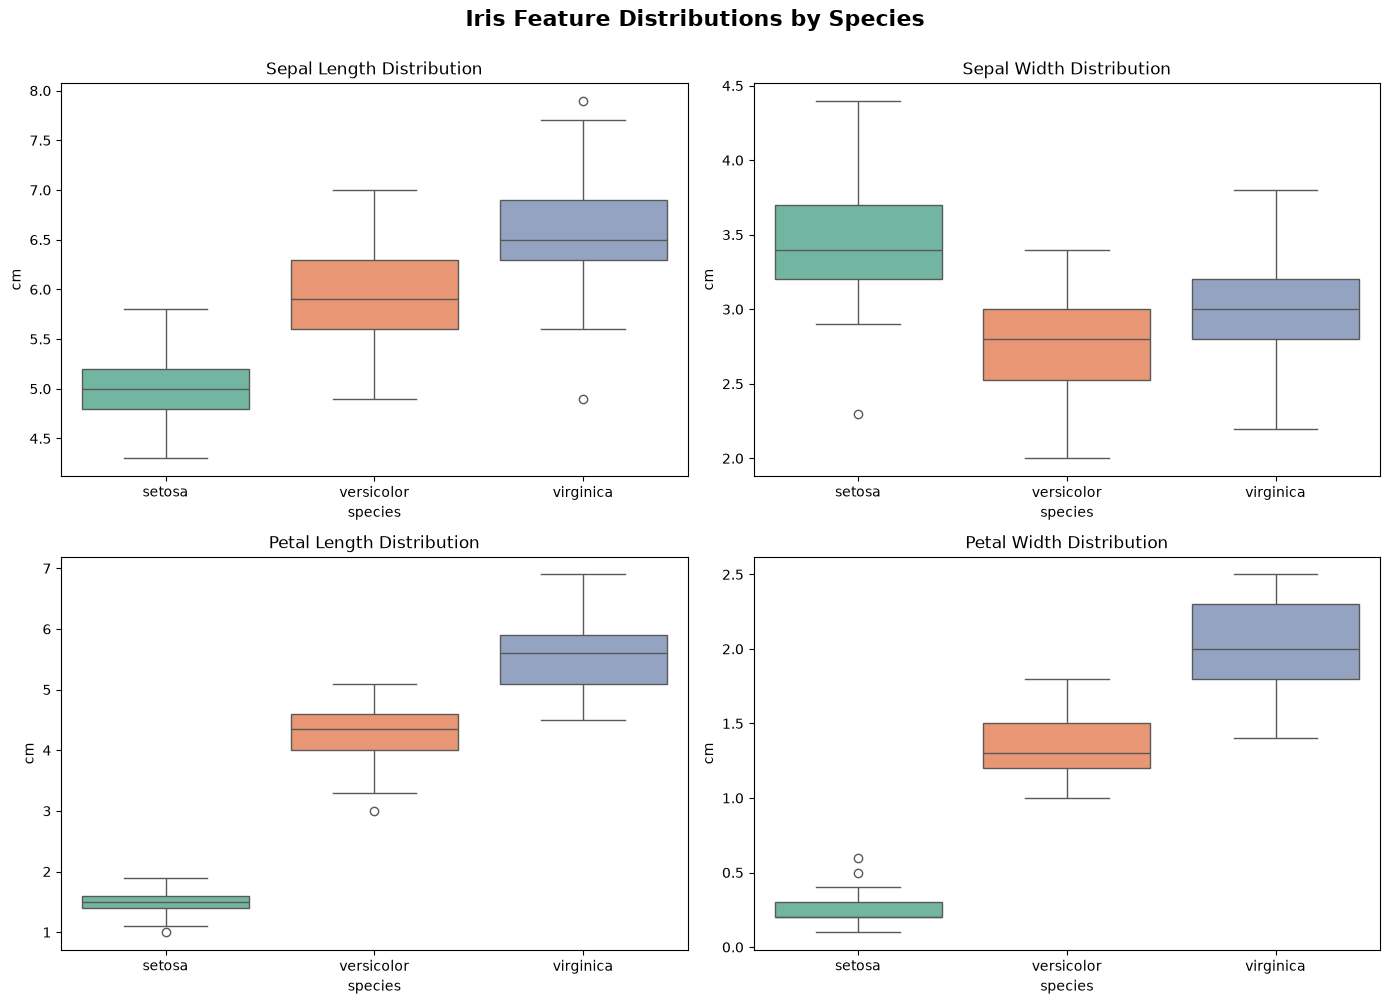

In [70]:
# Box plots

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Sepal Length
sns.boxplot(data=df, x="species", y="sepal_length", ax=axes[0, 0], palette="Set2")
axes[0, 0].set_title("Sepal Length Distribution")
axes[0, 0].set_ylabel("cm")

# Sepal Width
sns.boxplot(data=df, x="species", y="sepal_width", ax=axes[0, 1], palette="Set2")
axes[0, 1].set_title("Sepal Width Distribution")
axes[0, 1].set_ylabel("cm")

# Petal Length
sns.boxplot(data=df, x="species", y="petal_length", ax=axes[1, 0], palette="Set2")
axes[1, 0].set_title("Petal Length Distribution")
axes[1, 0].set_ylabel("cm")

# Petal Width
sns.boxplot(data=df, x="species", y="petal_width", ax=axes[1, 1], palette="Set2")
axes[1, 1].set_title("Petal Width Distribution")
axes[1, 1].set_ylabel("cm")

plt.suptitle("Iris Feature Distributions by Species", fontsize=16, fontweight='bold', y=1)
plt.tight_layout()
plt.show()

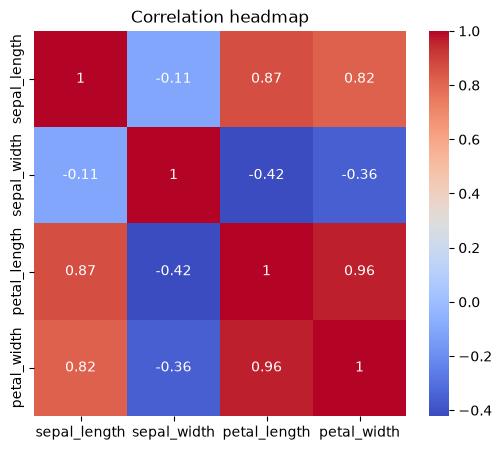

In [72]:
# correlation matrix

numeric_df = df.drop(columns=["species"])
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(6,5))

sns.heatmap(data= correlation_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation headmap")
plt.show()